In [1]:
from utils.binaries import *
from utils.plotting import *

from utils.auger.fd import XYScanner
from utils.auger.fd import PixelPlot

set_plt_style("slim tex")

04:33:30 (   +1.2s) [INFO   ] -- import logging
04:33:30 (  +196ms) [INFO   ] -- import numpy as np
04:33:30 (   +14ms) [INFO   ] -- import uncertainties
04:33:31 (  +831ms) [INFO   ] -- import pandas as pd
04:33:31 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
04:33:31 (    +2ms) [INFO   ] -- import binaries.tools as tools
04:33:31 (    +2ms) [INFO   ] -- set MONI_PATH = PosixPath('/cr/work/filip/monit_and_sd')
04:33:31 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/cr/work/filip/monit_and_sd')
04:33:31 (    +1ms) [INFO   ] -- set PLOT_PATH = PosixPath('/cr/data01/filip/plots')
04:33:31 (    +0ms) [INFO   ] -- set DATA_PATH = PosixPath('/cr/data01/filip/Data')
04:33:31 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/cr/data01/filip/xy-calibration')
04:33:31 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/cr/data01/filip/offline/install')
04:33:32 (  +638ms) [INFO   ] -- import matplotlib.pyplot as plt
04:33:33 (   +1.3s) [INFO   ] -- import seaborn a

In [2]:
CO4 = XYScanner.Telescope("CO4")

CO4

            preDAQ    preXY    XY      postXY    postDAQ
----------  --------  -------  ------  --------  ---------
2019-11-23  14220m22           14228   14232     14233
2022-10-15  15440m22  15450    15451   15452     15459m22
2023-11-08  15929m22  15930    15934x  15939     15956m22
2024-11-19  16405m22  16414    16415   16416     16417m22

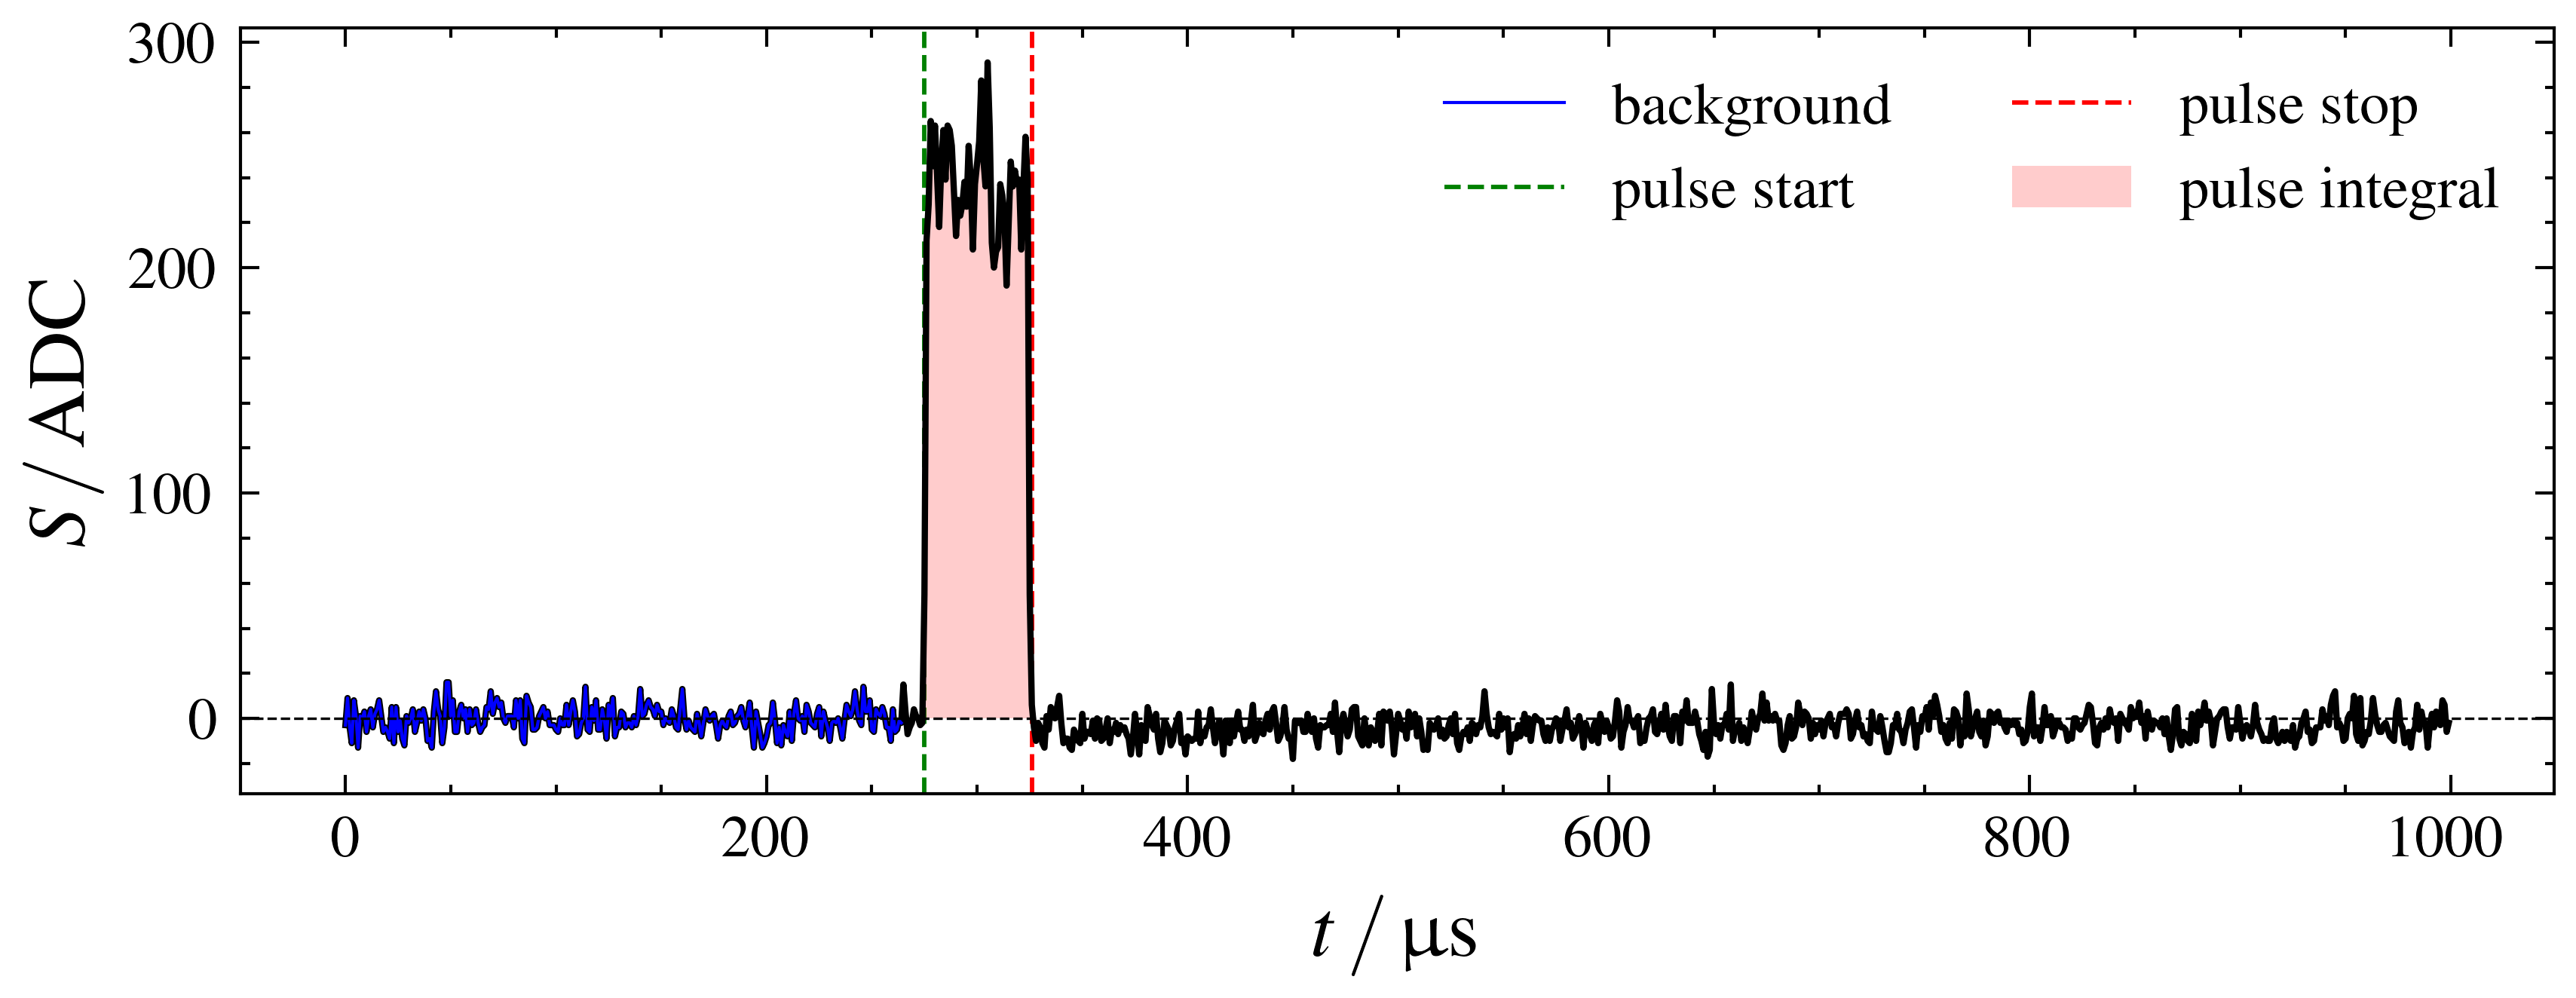

In [3]:

CO4_run = CO4[1].get_id("XY")
traces_to_plot = [195]
pixel = 210

traces = np.loadtxt(f"/cr/data01/filip/Data/CalXY_pixel_traces/dumpedTraces_{CO4_run}_pixel{pixel}.txt")
start, stop, flag = np.loadtxt(f"/cr/data01/filip/Data/CalXY_pixel_traces/pulseTiming_{CO4_run}.txt", 
                               usecols=[1, 2, -1], unpack=True, dtype=int)

for i, trace in enumerate(traces):

    if i not in traces_to_plot: continue

    plt.bar(np.arange(start[i]+1, stop[i]), trace[start[i]+1:stop[i]],
            width=1, color='r', alpha=0.2, label='pulse integral')
    plt.plot(np.arange(len(trace)), trace, marker='none')
    plt.plot(np.arange(len(trace[:start[i]-10])), 
             trace[:start[i]-10], marker='none',
             lw=0.5, ls='-', zorder=2, c='b', label='background')
    
    plt.axvline(start[i], zorder=0, c='g', ls='--', lw=0.7, label='pulse start')
    plt.axvline(stop[i], zorder=0, c='r', ls='--', lw=0.7, label='pulse stop')
    plt.axhline(0, c='k', lw=0.4, ls='--')

plt.xlabel(r"$t\,/\,\upmu\mathrm{s}$")
plt.ylabel("$S\,/\,\mathrm{ADC}$")
plt.legend(ncol=2)

plot.save(plt.gcf(), 'xy_trace_example')

04:39:10 (  +21.7s) [DEBUG  ] -- font size set to 9.5
04:39:10 (    +2ms) [DEBUG  ] -- label size set to 13.0
04:39:10 (    +1ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
04:39:10 (    +2ms) [DEBUG  ] -- markersize set to 2.0
04:39:10 (    +1ms) [DEBUG  ] -- usetex set to True


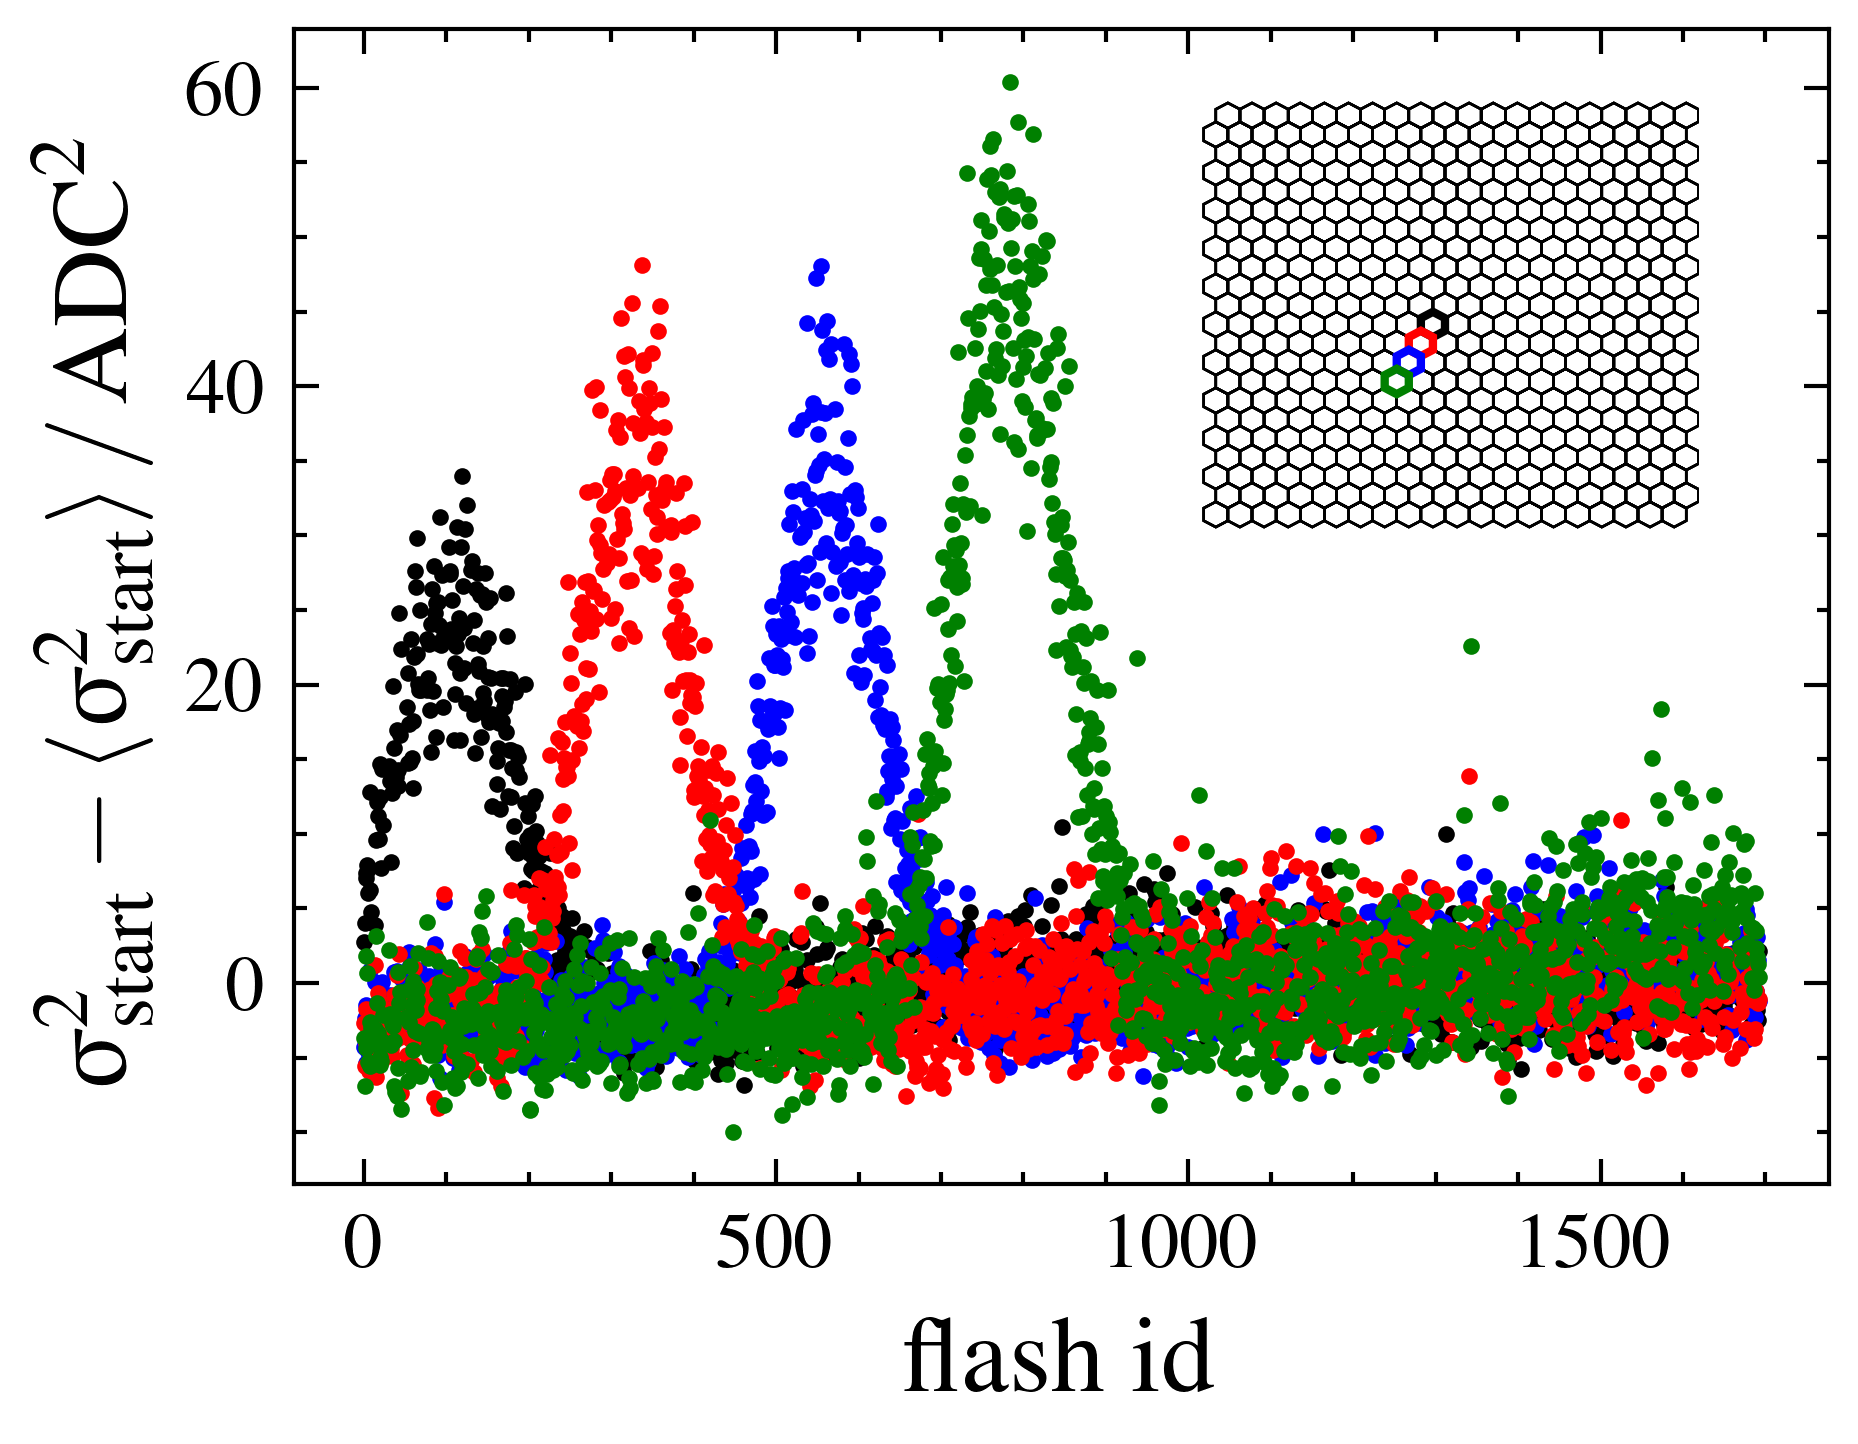

In [7]:
pixels_to_plot = np.array([210, 189, 190, 169])

set_plt_style("double tex")

for pixel in pixels_to_plot:

    traces = np.loadtxt(f"/cr/data01/filip/Data/CalXY_pixel_traces/dumpedTraces_{CO4_run}_pixel{pixel}.txt")
    start, stop, flag = np.loadtxt(f"/cr/data01/filip/Data/CalXY_pixel_traces/pulseTiming_{CO4_run}.txt", 
                                usecols=[1, 2, -1], unpack=True, dtype=int)

    flash_ids = np.zeros_like(flag) + np.nan
    start_variance = np.zeros_like(flag) + np.nan
    # flash_ids = np.zeros_like(flag) + np.nan

    for i in range(len(traces)):

        if flag[i] != -1: continue

        start_variance[i] = np.var(traces[i][:start[i] - 10])
        flash_ids[i] = i

    plt.scatter(flash_ids, start_variance - np.nanmedian(start_variance), lw=0, zorder=-pixel)

ax2 = plt.gca().inset_axes([0.55, 0.55, 0.40, 0.40])

for pix, c in zip(pixels_to_plot, ['k', 'r', 'b', 'g']):

    PixelPlot([np.nan] * 440, ax=ax2, vmin=0, vmax=1, lw=0.3,
            markpixels=[pix], markcolor=c)

plt.ylabel(r"$\upsigma^2_\mathrm{start} - \langle \upsigma^2_\mathrm{start}\rangle\,/\,\mathrm{ADC}^2$")
plt.xlabel("flash id")
plot.save(plt.gcf(), "star_transition")

In [9]:
test = tools.pickle_load("/cr/tempdata01/filip/xy_variances/nsb_fit2.pkl")


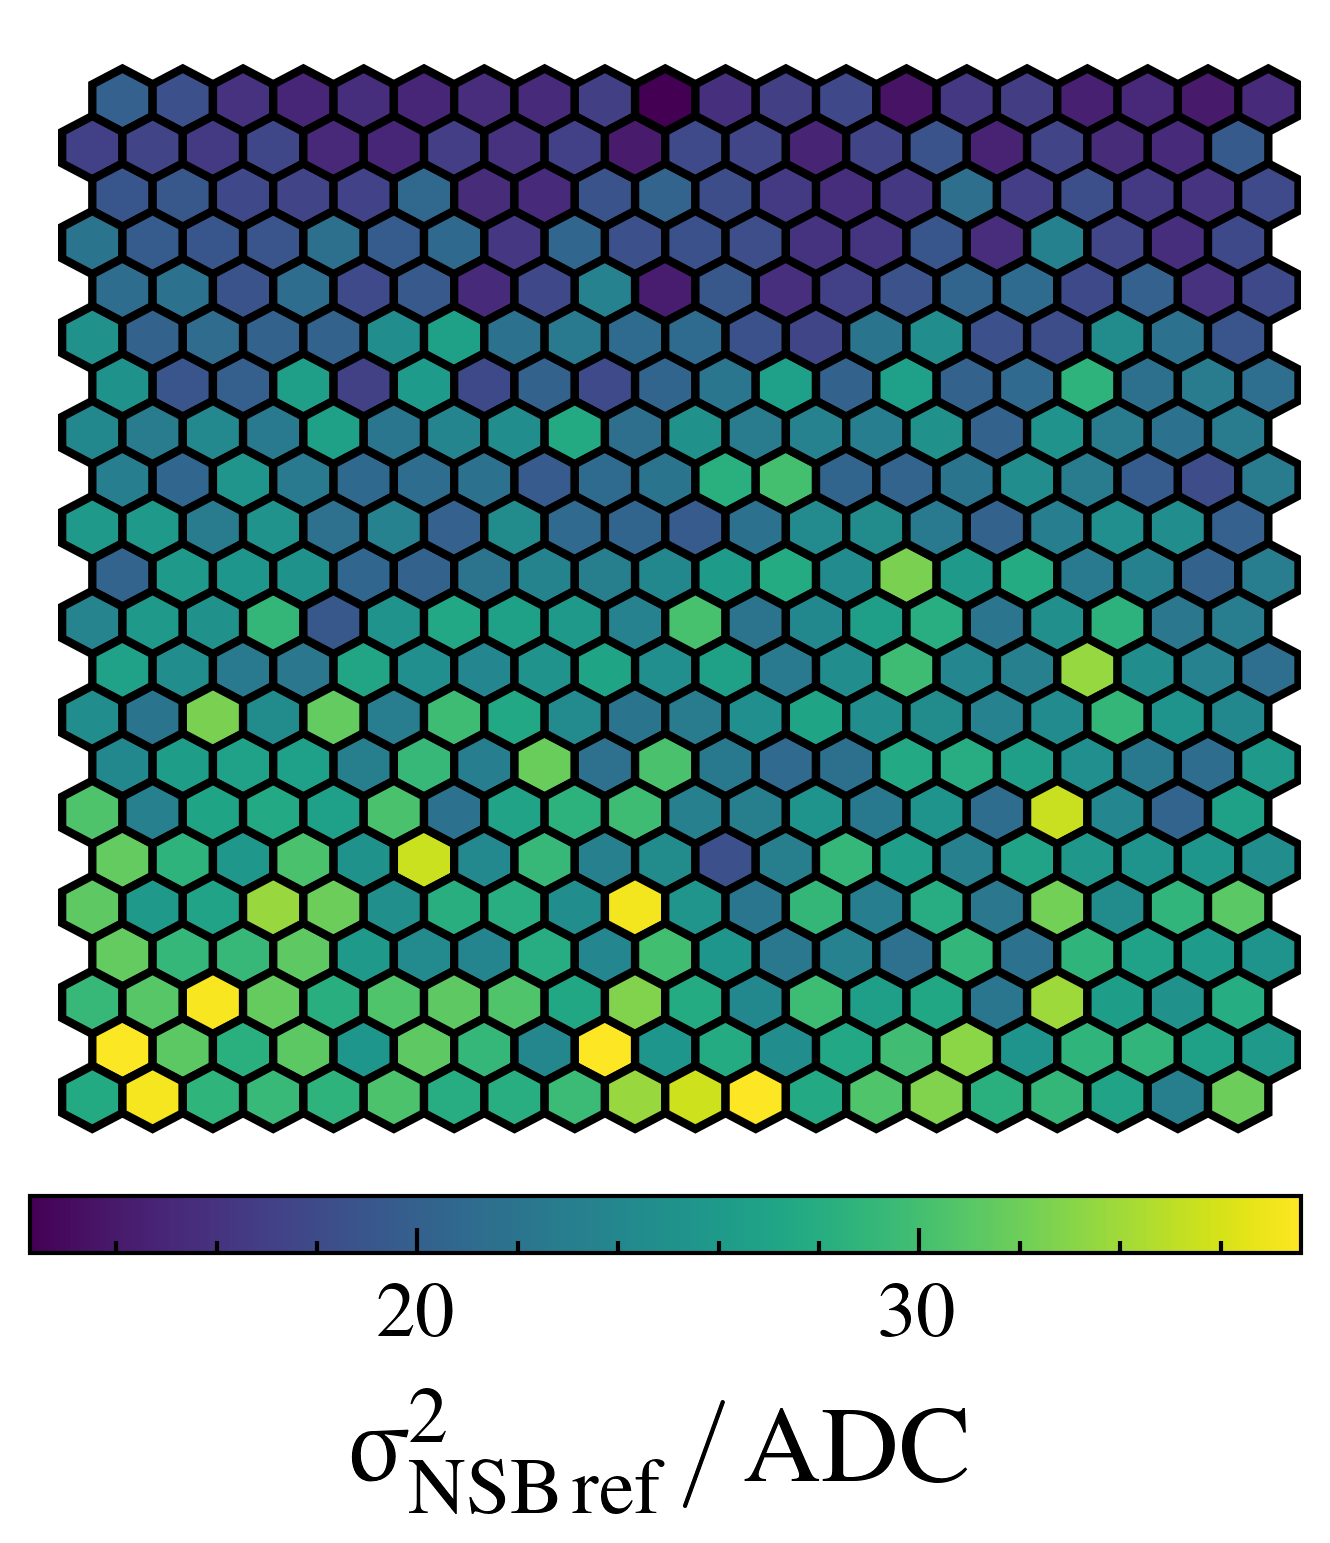

In [10]:
data = np.array(test['LL2_2024-11-26'][0])

ax = PixelPlot(data)
cax = ax.inset_axes([0, -0.06, 1, 0.05])

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

plt.colorbar(ScalarMappable(Normalize(data.min(), data.max())), cax=cax,
             orientation='horizontal', label=r'$\upsigma^2_{\mathrm{NSB}\,\mathrm{ref}}\,/\,\mathrm{ADC}$')

# plt.tight_layout()

plot.save(plt.gcf(), "nsb_ref_level")



In [119]:
np.array(test['LL2_2024-11-26'][0]).max()

np.float64(37.5898501680757)